In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

In [15]:
def plot_bode(freq, gain, phase):
    title1 = input("左側グラフ（利得）のタイトルを入力してください: ").strip()
    title2 = input("右側グラフ（位相）のタイトルを入力してください: ").strip()

    label_size = 14
    title_size = 18

    # 横に2つ並べる：1行2列
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))  # 横方向に並べる

    # --- 電圧利得（Gain） ---
    ax1.set_xscale('log')
    ax1.plot(freq, gain, marker='o', color='skyblue')
    ax1.set_xlabel("周波数 [Hz]", fontsize=label_size)
    ax1.set_ylabel("電圧利得 [dB]", fontsize=label_size)
    ax1.grid(which='both', linestyle='--', linewidth=0.5)
    ax1.set_title(title1, fontsize=title_size)

    # --- 位相差（Phase） ---
    ax2.set_xscale('log')
    ax2.plot(freq, phase, marker='o', color='orange')
    ax2.set_xlabel("周波数 [Hz]", fontsize=label_size)
    ax2.set_ylabel("位相差 [°]", fontsize=label_size)
    ax2.grid(which='both', linestyle='--', linewidth=0.5)
    ax2.set_title(title2, fontsize=title_size)

    # レイアウト調整
    plt.subplots_adjust(wspace=0.6)
    fig.tight_layout(pad=2.0)
    #自動保存したい場合は以下の#を消す。
    save_name=input("保存する名前を入力(.pngをつけること): ")
    plt.savefig(save_name)
    plt.show()

In [10]:
#freqとgainとphase求める関数
#列名を引数にする
def gain_and_phase():
    filename = input("CSVファイル名を入力してください（例: data.csv）: ").strip()
    filename = f"../Datasets/{filename}"
    try:
        df = pd.read_csv(filename)
    except FileNotFoundError:
        print(f"ファイルが見つかりません: {filename}")
        return

    print("\n利用可能な列:", df.columns.tolist())

    #ユーザーinput
    freq_col = input("周波数列の名前を入力してください（例: freq）: ").strip()
    vout_col = input("出力電圧列の名前を入力してください（例: v_out）: ").strip()
    vin_col = float(input("入力電圧列の値を入力してください: "))
    t_col = input("時間遅れの名前を入力してください（例: t）: ").strip()

    #freq
    freq = df[freq_col]

    #gain
    df["gain"] = 20*np.log10(df[vout_col] / 2)
    gain = df["gain"]

    #phase
    df["phase"] = 360*df[freq_col]*df[t_col]
    phase = df["phase"]
    return freq, gain, phase

In [4]:
f, g, p = gain_and_phase()

CSVファイル名を入力してください（例: data.csv）:  反転増幅回路周波数Vin = 2.csv



利用可能な列: ['W(Hz)', 'Vout', 'phase', 't(s)']


周波数列の名前を入力してください（例: freq）:  W(Hz)
出力電圧列の名前を入力してください（例: v_out）:  Vout
入力電圧列の値を入力してください:  2
時間遅れの名前を入力してください（例: t）:  t(s)


左側グラフ（利得）のタイトルを入力してください:  電圧利得
右側グラフ（位相）のタイトルを入力してください:  位相
保存する名前を入力(.pngをつけること):  jikken1-3.png


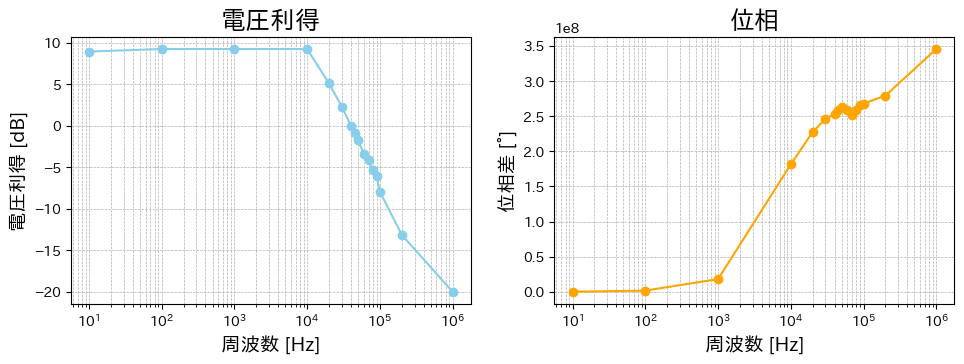

In [16]:
plot_bode(f, g, p)

In [18]:
f, g, p = gain_and_phase()

CSVファイル名を入力してください（例: data.csv）:  不完全積分0.033マイクロ.csv



利用可能な列: ['W(Hz)', 'Vpp(V)', 't(s)']


周波数列の名前を入力してください（例: freq）:  W(Hz)
出力電圧列の名前を入力してください（例: v_out）:  Vpp(V)
入力電圧列の値を入力してください:  2
時間遅れの名前を入力してください（例: t）:  t(s)


左側グラフ（利得）のタイトルを入力してください:  電圧利得
右側グラフ（位相）のタイトルを入力してください:  位相
保存する名前を入力(.pngをつけること):  jikken3.png


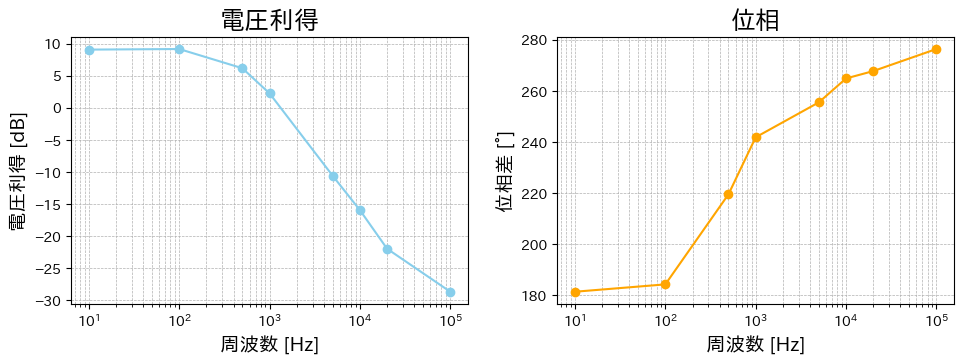

In [19]:
plot_bode(f, g, p)

In [20]:
def gain():
    filename = input("CSVファイル名を入力してください（例: data.csv）: ").strip()
    filename = f"../Datasets/{filename}"
    try:
        df = pd.read_csv(filename)
    except FileNotFoundError:
        print(f"ファイルが見つかりません: {filename}")
        return

    print("\n利用可能な列:", df.columns.tolist())

    #ユーザーinput
    freq_col = input("周波数列の名前を入力してください（例: freq）: ").strip()
    vout_col = input("出力電圧列の名前を入力してください（例: v_out）: ").strip()
    vin_col = float(input("入力電圧列の値を入力してください: "))

    #freq
    freq = df[freq_col]

    #gain
    df["gain"] = 20*np.log10(df[vout_col] / 2)
    gain = df["gain"]

    return freq, gain


def plot_bode_gain(freq, gain):
    title = input("グラフのタイトルを入力してください: ").strip()
    
    label_size = 14
    title_size = 18

    # 図の作成
    plt.figure(figsize=(8, 5))
    plt.plot(freq, gain, marker='o', color='skyblue')

    plt.xscale('log')
    plt.xlabel("周波数 [Hz]", fontsize=label_size)
    plt.ylabel("電圧利得 [dB]", fontsize=label_size)
    plt.title(title, fontsize=title_size)
    plt.grid(which='both', linestyle='--', linewidth=0.5)

    # レイアウトと保存
    plt.tight_layout(pad=2.0)

    save_name = input("保存するファイル名を入力してください（例: gain.png）: ").strip()
    if not save_name.endswith(".png"):
        save_name += ".png"
    
    plt.savefig(save_name)
    print(f"{save_name} に保存しました。")
    plt.show()

In [25]:
f, g = gain()

CSVファイル名を入力してください（例: data.csv）:  コンデンサ47マイクロ.csv



利用可能な列: ['W(Hz)', 'Vpp_in', 'V_pp_out', 'cp']


周波数列の名前を入力してください（例: freq）:  W(Hz)
出力電圧列の名前を入力してください（例: v_out）:  V_pp_out
入力電圧列の値を入力してください:  1.92


グラフのタイトルを入力してください:  電圧利得
保存するファイル名を入力してください（例: gain.png）:  jikken2.png


jikken2.png に保存しました。


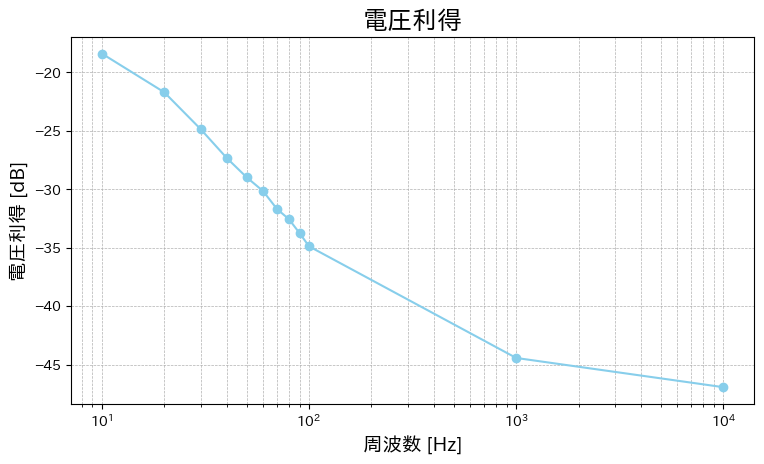

In [26]:
plot_bode_gain(f, g)

In [37]:
#ノーマルプロット
def plot():
    filename = input("CSVファイル名を入力してください（例: data.csv）: ").strip()
    filename = f"../Datasets/{filename}"
    try:
        df = pd.read_csv(filename)
    except FileNotFoundError:
        print(f"ファイルが見つかりません: {filename}")
        return

    print("\n利用可能な列:", df.columns.tolist())

    #ユーザーinput
    vin_col = input("入力電圧列の名前を入力してください（例: freq）: ").strip()
    vout_col = input("出力電圧列の名前を入力してください（例: v_out）: ").strip()

    v_in = df[vin_col]
    v_out = df[vout_col]

    title = input("グラフのタイトルを入力してください: ").strip()
    
    label_size = 14
    title_size = 18

    # 図の作成
    plt.figure(figsize=(7, 5))
    plt.plot(v_in, v_out, marker='o', color='skyblue')
    plt.xlabel(r"$V_{in}$ [V]", fontsize=label_size)
    plt.ylabel(r"$V_{out}$ [V]", fontsize=label_size)
    plt.title(title, fontsize=title_size)
    plt.grid(which='both', linestyle='--', linewidth=0.5)

    # レイアウトと保存
    plt.tight_layout(pad=2.0)

    save_name = input("保存するファイル名を入力してください（例: gain.png）: ").strip()
    if not save_name.endswith(".png"):
        save_name += ".png"
    
    plt.savefig(save_name)
    print(f"{save_name} に保存しました。")
    plt.show()

CSVファイル名を入力してください（例: data.csv）:  反転増幅回路V=+-5.csv



利用可能な列: ['V_in(V)', 'V_out(V)']


入力電圧列の名前を入力してください（例: freq）:  V_in(V)
出力電圧列の名前を入力してください（例: v_out）:  V_out(V)
グラフのタイトルを入力してください:  電源電圧$\pm 5 V$の入出力特性
保存するファイル名を入力してください（例: gain.png）:  jikken1-1.png


jikken1-1.png に保存しました。


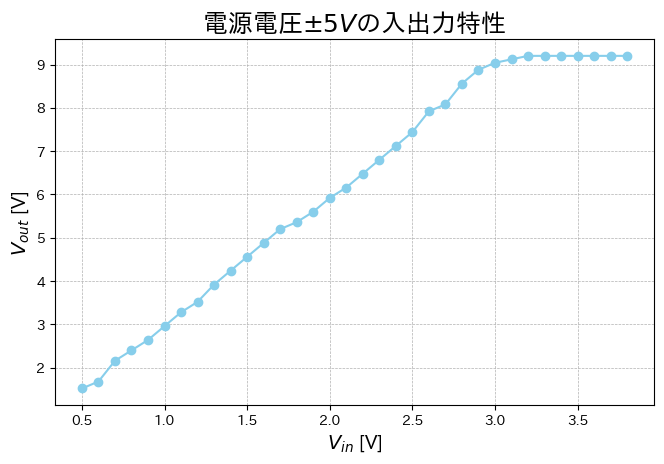

In [38]:
plot()

CSVファイル名を入力してください（例: data.csv）:  反転増幅V+-10.csv



利用可能な列: ['V_in', 'V_out']


入力電圧列の名前を入力してください（例: freq）:  V_in
出力電圧列の名前を入力してください（例: v_out）:  V_out
グラフのタイトルを入力してください:  電源電圧$\pm 10 V$の入出力特性
保存するファイル名を入力してください（例: gain.png）:  jikken1-2.png


jikken1-2.png に保存しました。


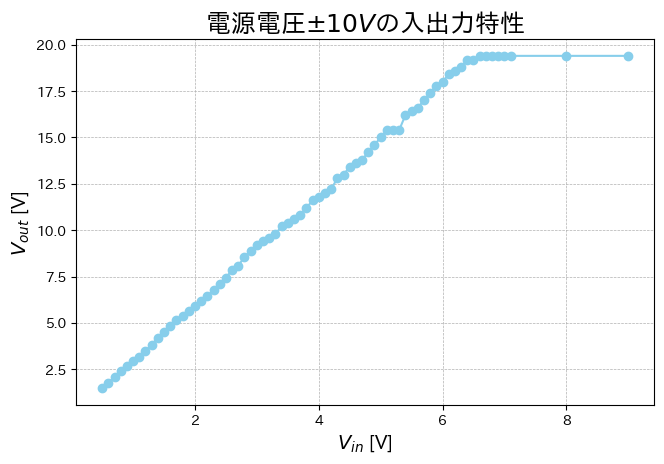

In [41]:
plot